# 16 - Uso de Word2Vec Preentrenado
 
Goal: Ejemplo de uso de embeddings Word2Vec preentrenados en un modelo Keras simple.
 
Run with: conda activate tfenv

In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import plotly.express as px
import pandas as pd
import time

print(f"TensorFlow version: {tf.__version__}")

I0000 00:00:1779051362.783039   30712 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1779051363.048357   30712 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1779051367.007154   30712 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


TensorFlow version: 2.21.0


In [2]:
# Importar embeddings Word2Vec entrenados previamente
class MyWord2Vec():
	def __init__(self, path='../myWord2Vec/'):
		super(MyWord2Vec, self).__init__()
		target_embeddings = np.load(path + 'target_embeddings.npy')
		context_embeddings = np.load(path + 'context_embeddings.npy')
		text_vocab = np.load(path + 'text_vocab.npy', allow_pickle=True).item()
		self.layer = layers.Embedding(
			input_dim=target_embeddings.shape[0],
			output_dim=target_embeddings.shape[1],
			weights=[target_embeddings],
			trainable=False,  # O True si quieres ajustar
			name='pretrained_embedding'
		)
		self.target_embeddings = target_embeddings
		self.context_embeddings = context_embeddings
		self.text_vocab = text_vocab
		self.final_embeddings = (target_embeddings + context_embeddings) / 2
		print('Embeddings cargados:', target_embeddings.shape, context_embeddings.shape, 'Vocabulario cargado:', len(text_vocab))

	def __call__(self, token):
		token_id = self.text_vocab.get(token)
		if token_id is None:
			raise ValueError(f"Token '{token}' no encontrado en el vocabulario.")
		return self.final_embeddings[token_id]

myWord2Vec = MyWord2Vec()

Embeddings cargados: (807, 64) (807, 64) Vocabulario cargado: 807


E0000 00:00:1779051372.786275   30712 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1779051372.821558   30712 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [3]:
myWord2Vec('bank')

array([-0.28501534, -0.5073903 ,  0.3754411 , -0.16484009, -0.1826826 ,
       -0.5811516 ,  0.25318754, -0.20066723, -0.03234106, -0.1983294 ,
        0.22193125, -0.07133868, -1.1277426 , -0.14788602,  0.00594485,
        0.06697989,  0.2680027 ,  0.30610293,  0.02022836, -0.14936   ,
       -0.35025677,  0.9948102 , -0.29224348,  0.27824396, -0.06160453,
        0.96823585, -1.0880908 ,  0.20591159,  0.35358378,  0.03991617,
       -0.0276342 ,  0.5968418 ,  0.7929538 ,  0.74884087,  0.40281463,
        0.12895238,  0.45341355, -1.1052495 , -0.4245516 ,  0.03584774,
        0.6724809 ,  0.08946411, -0.08444281, -0.40274462,  0.22121572,
       -1.2098794 ,  0.04220062,  0.5373121 , -0.3225735 ,  0.08055313,
       -0.16905993, -0.16546796, -0.26491246, -0.31321383,  0.10717484,
       -0.14396463, -0.86192745,  0.5560495 ,  0.08061355, -0.07986355,
        0.5029609 , -0.38039207,  0.655138  ,  0.38013253], dtype=float32)

In [4]:
# Ejemplo: Clasificación de palabras (dataset ampliado) usando embeddings preentrenados
import random
from sklearn.model_selection import train_test_split

# Vocabulario y semilla positiva
vocab_list = list(myWord2Vec.text_vocab.keys())
positive_seed = [p for p in ['london', 'palace', 'museum', 'queen', 'bank'] if p in vocab_list]
if not positive_seed:
    positive_seed = vocab_list[:5]  # fallback

# Generar dataset sintético más grande
n_samples = 1000
words = []
labels = []
for _ in range(n_samples):
    if random.random() < 0.3 and positive_seed:
        p = random.choice(positive_seed)
        label = 1
    else:
        p = random.choice(vocab_list)
        label = 1 if p in positive_seed else 0
    words.append(p)
    labels.append(label)

# Convertir a índices y arreglos
indices = [myWord2Vec.text_vocab[p] for p in words]
X = np.array(indices)
y = np.array(labels)

# Split 80/20 (estratificado si hay ambas clases)
stratify = y if len(np.unique(y)) > 1 else None
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=stratify)

# Crear tf.data.Dataset
batch_size = 32
train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train)).shuffle(1000).batch(batch_size).prefetch(tf.data.AUTOTUNE)
val_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test)).batch(batch_size).prefetch(tf.data.AUTOTUNE)

# Modelo simple: usa la capa de embedding preentrenada
model = keras.Sequential([
    layers.Input(shape=(), dtype='int32'),
    myWord2Vec.layer,  # Capa de embedding preentrenada
    layers.Flatten(),
    layers.Dense(32, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

# Entrenar con validation (20%)
history = model.fit(train_ds, epochs=10, validation_data=val_ds, verbose=1)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ pretrained_embedding            │ (None, 64)             │        51,648 │
│ (Embedding)                     │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 53,761 (210.00 KB)

 Trainable params: 2,113 (8.25 KB)

 Non-trainable params: 51,648 (201.75 KB)

Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.7887 - loss: 0.5334 - val_accuracy: 0.8600 - val_loss: 0.4255
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9137 - loss: 0.3428 - val_accuracy: 0.8950 - val_loss: 0.2982
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9287 - loss: 0.2409 - val_accuracy: 0.8950 - val_loss: 0.2272
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9350 - loss: 0.1803 - val_accuracy: 0.8950 - val_loss: 0.1818
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9425 - loss: 0.1404 - val_accuracy: 0.9850 - val_loss: 0.1495
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9975 - loss: 0.1122 - val_accuracy: 0.9850 - val_loss: 0.1277
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9975 - loss: 0.0924 - val_accuracy: 0.9800 - val_loss: 0.1110
Epoch 8/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9975 - loss: 0.0767 - val_accuracy: 0.9800 - val_loss

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
Test accuracy: 0.980
              precision    recall  f1-score   support

           0       1.00      0.97      0.98       135
           1       0.94      1.00      0.97        65

    accuracy                           0.98       200
   macro avg       0.97      0.99      0.98       200
weighted avg       0.98      0.98      0.98       200

       Palabra  Etiqueta_verdadera  Predicción  Predicción_binaria
0   passengers                   0        0.00                   0
1       museum                   1        0.96                   1
2       london                   1        0.71                   1
3       palace                   1        0.97                   1
4        which                   0        0.34                   0
5       stands                   0        0.18                   0
6        scene                   0        0.00                   0
7         sikh                   0        0.00                   0
8       hos

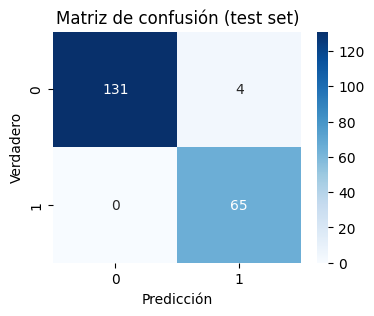

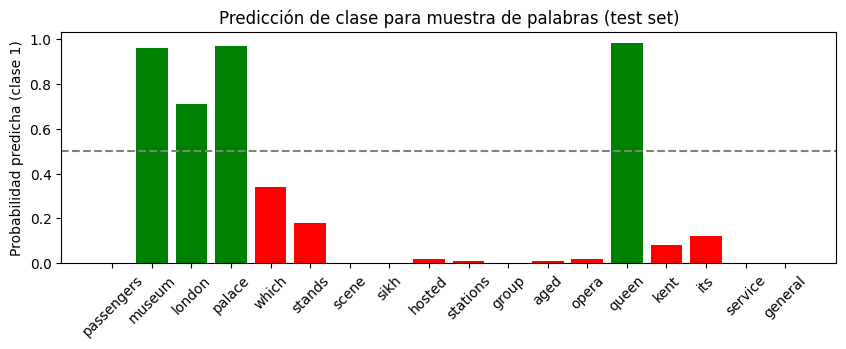

In [5]:
# Visualización de resultados: métricas sobre el test set
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns

# Predecir sobre X_test (ya en memoria)
y_pred = model.predict(X_test).flatten()
y_pred_bin = (y_pred > 0.5).astype(int)

# Métricas
acc = accuracy_score(y_test, y_pred_bin)
print(f"Test accuracy: {acc:.3f}")
print(classification_report(y_test, y_pred_bin))

# Mostrar resultados en tabla para las primeras 20 palabras del test set
sample_n = min(20, len(X_test))
sample_idx = np.random.choice(len(X_test), size=sample_n, replace=False)
words_sample = [list(myWord2Vec.text_vocab.keys())[list(myWord2Vec.text_vocab.values()).index(int(X_test[i]))] for i in sample_idx]
df = pd.DataFrame({
    'Palabra': words_sample,
    'Etiqueta_verdadera': y_test[sample_idx],
    'Predicción': y_pred[sample_idx].round(2),
    'Predicción_binaria': y_pred_bin[sample_idx]
})
print(df)

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred_bin)
plt.figure(figsize=(4,3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['0','1'], yticklabels=['0','1'])
plt.xlabel('Predicción')
plt.ylabel('Verdadero')
plt.title('Matriz de confusión (test set)')
plt.show()

# Gráfico de probabilidades para las primeras 20 muestras mostradas
plt.figure(figsize=(10,3))
plt.bar(df['Palabra'], df['Predicción'], color=['green' if t==1 else 'red' for t in df['Etiqueta_verdadera']])
plt.axhline(0.5, color='gray', linestyle='--')
plt.ylabel('Probabilidad predicha (clase 1)')
plt.title('Predicción de clase para muestra de palabras (test set)')
plt.xticks(rotation=45)
plt.show()